# Selekcja cech i redukcja wymiarowości

## Konfiguracja

Użyjemy standardowych bibliotek oraz dodatkowo Seaborn dla wizualizacji.

**Uwaga:** upewnij się, że masz scikit-learn w wersji 1.2 lub nowszej. Dzięki temu będzie można ustawić opcję `transform_output="pandas"`, dzięki której wszystkie transformatory w scikit-learn będą nie tylko przyjmować, ale też zwracać DataFrame, zachowując nazwy zmiennych. Będzie to bardzo przydatne w analizie danych.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
import sklearn


sklearn.set_config(transform_output="pandas")

## Analiza cech

Ponownie wykorzystamy zbiór danych [Ames housing](https://www.openintro.org/book/statdata/?data=ames), w którym zadaniem jest przewidywanie wartości domu na podstawie cech budynku, działki, lokalizacji itp. Ma on duży zbiór wejściowych cech, odpowiadający typowym wartościom ze stron handlujących nieruchomościami, więc odpowiada realnym potrzebom analizy biznesowej.

Interpretowalność jest tutaj kluczowa, bo każdy sprzedający chce zyskać jak najwięcej. Informacja, które cechy nie mają znaczenia dla kupujących, a na które jest zwracana największa uwaga, mogą np. pokierować decyzjami, które części domu wyremontować przed ogłoszeniem sprzedaży. Z kolei cechy o niskiej ważności warto odrzucić nie tylko, aby pomóc modelowi ML, ale też żeby np. nie wspominać o tych elementach w ogłoszeniu, bo i tak mało kogo obchodzą.

Zmniejszenie liczby cech jest też korzystne dla samych firm IT oferujących serwisy sprzedażowe, bo może być ważne dla user experience (UX). Formularz na 70 elementów o różnych cechach domu jest mocno problematyczny do wypełnienia, a taki na 20 jest już znacznie przyjaźniejszy. Takie rzeczy jak najbardziej mogą decydować o tym, którą platformę do ogłoszeń wybiorą sprzedający.

Poniższy kod wczytuje dane i dokonuje podziału na zbiór treningowy i testowy.

**Uwaga:** będziemy operować na wielu kopiach danych do różnych wariantów procesowania danych. Nadpisanie zmiennej `X_train` z komórki poniżej może skutkować trudnymi do znalezienia bugami, zwróć na to uwagę.

In [ ]:
from sklearn.model_selection import train_test_split


df = pd.read_csv("ames_data.csv")

# remove dots from names to match data_description.txt
df.columns = [col.replace(".", "") for col in df.columns]

df = df.drop(["Order", "PID"], axis="columns")
df = df.loc[~df["Neighborhood"].isin(["GrnHill", "Landmrk"]), :]

df = df.loc[df["GrLivArea"] <= 4000, :]

df["SalePrice"] = np.log1p(df["SalePrice"].astype(float))


def replace_na(df: pd.DataFrame, col: str, value) -> None:
    df.loc[:, col] = df.loc[:, col].fillna(value)


# Alley : data description says NA means "no alley access"
replace_na(df, "Alley", value="None")

# BedroomAbvGr : NA most likely means 0
replace_na(df, "BedroomAbvGr", value=0)

# BsmtQual etc : data description says NA for basement features is "no basement"
replace_na(df, "BsmtQual", value="No")
replace_na(df, "BsmtCond", value="No")
replace_na(df, "BsmtExposure", value="No")
replace_na(df, "BsmtFinType1", value="No")
replace_na(df, "BsmtFinType2", value="No")
replace_na(df, "BsmtFullBath", value=0)
replace_na(df, "BsmtHalfBath", value=0)
replace_na(df, "BsmtUnfSF", value=0)

# Condition : NA most likely means Normal
replace_na(df, "Condition1", value="Norm")
replace_na(df, "Condition2", value="Norm")

# Electrical : NA most likely means standard
replace_na(df, "Electrical", value="SBrkr")

# External stuff : NA most likely means average
replace_na(df, "ExterCond", value="TA")
replace_na(df, "ExterQual", value="TA")

# Fence : data description says NA means "no fence"
replace_na(df, "Fence", value="No")

# Functional : data description says NA means typical
replace_na(df, "Functional", value="Typ")

# GarageType etc : data description says NA for garage features is "no garage"
replace_na(df, "GarageType", value="No")
replace_na(df, "GarageFinish", value="No")
replace_na(df, "GarageQual", value="No")
replace_na(df, "GarageCond", value="No")
replace_na(df, "GarageArea", value=0)
replace_na(df, "GarageCars", value=0)

# HalfBath : NA most likely means no half baths above grade
replace_na(df, "HalfBath", value=0)

# HeatingQC : NA most likely means typical
replace_na(df, "HeatingQC", value="Ta")

# KitchenAbvGr : NA most likely means 0
replace_na(df, "KitchenAbvGr", value=0)

# KitchenQual : NA most likely means typical
replace_na(df, "KitchenQual", value="TA")

# LotFrontage : NA most likely means no lot frontage
replace_na(df, "LotFrontage", value=0)

# LotShape : NA most likely means regular
replace_na(df, "LotShape", value="Reg")

# MasVnrType : NA most likely means no veneer
replace_na(df, "MasVnrType", value="None")
replace_na(df, "MasVnrArea", value=0)

# MiscFeature : data description says NA means "no misc feature"
replace_na(df, "MiscFeature", value="No")
replace_na(df, "MiscVal", value=0)

# OpenPorchSF : NA most likely means no open porch
replace_na(df, "OpenPorchSF", value=0)

# PavedDrive : NA most likely means not paved
replace_na(df, "PavedDrive", value="N")

# PoolQC : data description says NA means "no pool"
replace_na(df, "PoolQC", value="No")
replace_na(df, "PoolArea", value=0)

# SaleCondition : NA most likely means normal sale
replace_na(df, "SaleCondition", value="Normal")

# ScreenPorch : NA most likely means no screen porch
replace_na(df, "ScreenPorch", value=0)

# TotRmsAbvGrd : NA most likely means 0
replace_na(df, "TotRmsAbvGrd", value=0)

# Utilities : NA most likely means all public utilities
replace_na(df, "Utilities", value="AllPub")

# WoodDeckSF : NA most likely means no wood deck
replace_na(df, "WoodDeckSF", value=0)

# CentralAir : NA most likely means No
replace_na(df, "CentralAir", value="N")

# EnclosedPorch : NA most likely means no enclosed porch
replace_na(df, "EnclosedPorch", value=0)

# FireplaceQu : data description says NA means "no fireplace"
replace_na(df, "FireplaceQu", value="No")
replace_na(df, "Fireplaces", value=0)

# SaleCondition : NA most likely means normal sale
replace_na(df, "SaleCondition", value="Normal")

df = df.replace(
    {
        "MSSubClass": {
            20: "SC20",
            30: "SC30",
            40: "SC40",
            45: "SC45",
            50: "SC50",
            60: "SC60",
            70: "SC70",
            75: "SC75",
            80: "SC80",
            85: "SC85",
            90: "SC90",
            120: "SC120",
            150: "SC150",
            160: "SC160",
            180: "SC180",
            190: "SC190",
        },
        "MoSold": {
            1: "Jan",
            2: "Feb",
            3: "Mar",
            4: "Apr",
            5: "May",
            6: "Jun",
            7: "Jul",
            8: "Aug",
            9: "Sep",
            10: "Oct",
            11: "Nov",
            12: "Dec",
        },
    }
)

df = df.replace(
    {
        "Alley": {"None": 0, "Grvl": 1, "Pave": 2},
        "BsmtCond": {"No": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
        "BsmtExposure": {"No": 0, "Mn": 1, "Av": 2, "Gd": 3},
        "BsmtFinType1": {
            "No": 0,
            "Unf": 1,
            "LwQ": 2,
            "Rec": 3,
            "BLQ": 4,
            "ALQ": 5,
            "GLQ": 6,
        },
        "BsmtFinType2": {
            "No": 0,
            "Unf": 1,
            "LwQ": 2,
            "Rec": 3,
            "BLQ": 4,
            "ALQ": 5,
            "GLQ": 6,
        },
        "BsmtQual": {"No": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
        "ExterCond": {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
        "ExterQual": {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
        "FireplaceQu": {"No": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
        "Functional": {
            "Sal": 1,
            "Sev": 2,
            "Maj2": 3,
            "Maj1": 4,
            "Mod": 5,
            "Min2": 6,
            "Min1": 7,
            "Typ": 8,
        },
        "GarageCond": {"No": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
        "GarageQual": {"No": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
        "HeatingQC": {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
        "KitchenQual": {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
        "LandSlope": {"Sev": 1, "Mod": 2, "Gtl": 3},
        "LotShape": {"IR3": 1, "IR2": 2, "IR1": 3, "Reg": 4},
        "PavedDrive": {"N": 0, "P": 1, "Y": 2},
        "PoolQC": {"No": 0, "Fa": 1, "TA": 2, "Gd": 3, "Ex": 4},
        "Street": {"Grvl": 1, "Pave": 2},
        "Utilities": {"ELO": 1, "NoSeWa": 2, "NoSewr": 3, "AllPub": 4},
    }
)

y = df.pop("SalePrice")

X_train, X_test, y_train, y_test = train_test_split(
    df, y, test_size=0.3, random_state=0
)

X_train

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
2500,SC60,RL,105.0,11025,2,0,4,HLS,4,Inside,...,0,0,0,No,No,0,Oct,2006,WD,Normal
261,SC20,RL,75.0,10650,2,0,4,Lvl,4,Corner,...,0,0,0,MnPrv,No,0,Feb,2010,WD,Normal
1774,SC60,RL,82.0,9044,2,0,3,Lvl,4,Inside,...,0,0,0,No,No,0,May,2007,WD,Normal
2588,SC20,RL,80.0,13600,2,0,4,Bnk,4,Inside,...,0,0,0,MnPrv,Shed,650,Nov,2006,WD,Normal
1023,SC20,RL,90.0,13068,2,0,4,Lvl,4,Corner,...,0,0,0,MnPrv,No,0,Nov,2008,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,SC90,RL,60.0,10800,2,0,4,Lvl,4,Inside,...,0,0,0,No,No,0,Mar,2009,WD,Alloca
835,SC20,RL,82.0,12464,2,0,2,Low,4,Corner,...,0,0,0,GdPrv,No,0,Nov,2009,WD,Normal
1654,SC20,RL,80.0,10400,2,0,4,Lvl,4,Inside,...,0,0,0,No,No,0,Aug,2007,WD,Normal
2613,SC20,RL,60.0,7332,2,0,4,Lvl,4,Inside,...,0,0,0,No,No,0,Oct,2006,WD,Abnorml


Analiza cech kategorycznych i numerycznych wykorzystuje często różne metody i wymaga innego preprocessingu. Dodatkowo one-hot encoding bardzo utrudnia interpretację cech kategorycznych, dlatego trzeba się zastanowić, na którym etapie przetwarzania danych dokonujemy sprawdzania ważności cech danym algorytmem.

Na początek skupimy się na zmiennych numerycznych. Podstawową metodą jest sprawdzenie wariancji tych danych. Wymaga to danych bez wartości brakujących i o tej samej skali.

**Uwaga:** nie można tutaj dokonać standaryzacji! Wtedy dzieli się przez odchylenie standardowe, więc wszystko ma wariancję 1. Trzeba dokonać przeskalowania przez min-max scaling.

In [5]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler


X_train_num = X_train.select_dtypes(exclude="object")

numerical_pipeline = make_pipeline(SimpleImputer(strategy="median"), MinMaxScaler())

X_train_num = numerical_pipeline.fit_transform(X_train_num)
X_train_num

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,X3SsnPorch,ScreenPorch,PoolArea,MiscVal,YrSold
2500,0.335463,0.044697,0.777778,0.500,0.868217,0.716667,0.432500,0.488636,0.000000,0.092466,...,0.75,0.596774,0.124298,0.280323,0.183794,0.00000,0.0,0.0,0.000,0.00
261,0.239617,0.042942,0.444444,0.625,0.744186,0.433333,0.000000,0.079545,0.466579,0.000000,...,0.25,0.206989,0.256320,0.000000,0.000000,0.00000,0.0,0.0,0.000,1.00
1774,0.261981,0.035430,0.777778,0.500,0.899225,0.783333,0.328750,0.535402,0.000000,0.042808,...,0.75,0.627016,0.139045,0.123989,0.000000,0.00000,0.0,0.0,0.000,0.25
2588,0.255591,0.056742,0.444444,0.625,0.581395,0.083333,0.000000,0.062937,0.597641,0.000000,...,0.25,0.201613,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.052,0.00
1023,0.287540,0.054253,0.555556,0.500,0.744186,0.433333,0.388125,0.388986,0.031455,0.116866,...,0.50,0.309812,0.000000,0.000000,0.000000,0.34252,0.0,0.0,0.000,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,0.191693,0.043644,0.444444,0.500,0.829457,0.633333,0.000000,0.524476,0.000000,0.000000,...,0.00,0.000000,0.084270,0.000000,0.000000,0.00000,0.0,0.0,0.000,0.75
835,0.261981,0.051428,0.444444,0.500,0.899225,0.766667,0.000000,0.319930,0.000000,0.131849,...,0.50,0.387097,0.117978,0.000000,0.000000,0.00000,0.0,0.0,0.000,0.75
1654,0.255591,0.041773,0.555556,0.500,0.767442,0.816667,0.158125,0.394668,0.000000,0.152397,...,0.50,0.321237,0.168539,0.190027,0.000000,0.00000,0.0,0.0,0.000,0.25
2613,0.191693,0.027421,0.555556,0.625,0.612403,0.150000,0.129375,0.180944,0.000000,0.192637,...,0.25,0.193548,0.117978,0.000000,0.000000,0.00000,0.0,0.0,0.000,0.00


Do usuwania cech o niskiej wariancji służy klasa `VarianceThreshold`. Jaki jednak ustawić próg wariancji? To dobrze byłoby najpierw sprawdzić na wykresie, bo w zależności od zbioru dane po prostu ogólnie mogą mieć mniejszą lub większą zmienność.

**Zadanie 1 (0.5 punktu)**

1. Oblicz wariancję dla cech w danych treningowych.
2. Posortuj cechy w kolejności od największej do najmniejszej wariancji.
3. Wypisz cechy o najmniejszej wariancji (razem z jej wartościami).
4. Przedstaw to na wykresie słupkowym (bar plot). Pamiętaj o tytule wykresu, opisaniu osi i cech. Upewnij się, że ma odpowiednią wielkość, aby nazwy cech były czytelne.
5. Zinterpretuj wykres i skomentuj:
   - jaki twoim zdaniem byłby sensowny próg wariancji?
   - czy jest cecha / cechy, które twoim zdaniem są tak mało zmienne, że są bezużyteczne?
   - czy twoim zdaniem cechy o największej wariancji wydają się bardzo użyteczne?

Podpowiedź: każdy z podpunktów da się zrobić jedną metodą na DataFrame'ie.

Cechy o najmniejszej wariancji:
BsmtFinSF2       0.013841
X1stFlrSF        0.012005
MasVnrArea       0.011946
LotFrontage      0.011413
KitchenAbvGr     0.010879
ScreenPorch      0.010149
BedroomAbvGr     0.010134
OpenPorchSF      0.008114
WoodDeckSF       0.007848
EnclosedPorch    0.004215
X3SsnPorch       0.002651
LowQualFinSF     0.002047
PoolArea         0.001719
LotArea          0.001347
MiscVal          0.001092
dtype: float64


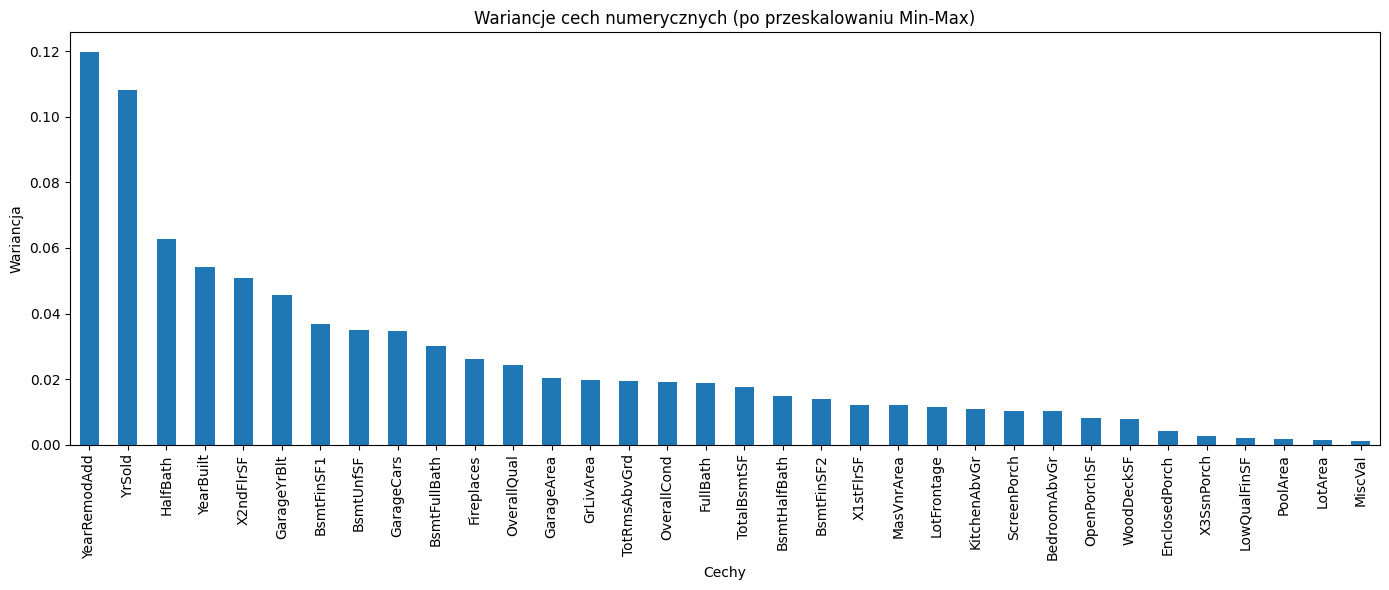

In [6]:
variances = X_train_num.var()

variances_sorted = variances.sort_values(ascending=False)

print("Cechy o najmniejszej wariancji:")
print(variances_sorted.tail(15))

plt.figure(figsize=(14, 6))
variances_sorted.plot(kind="bar")
plt.title("Wariancje cech numerycznych (po przeskalowaniu Min-Max)")
plt.xlabel("Cechy")
plt.ylabel("Wariancja")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Interpretacja Zadania 1:

* **Sensowny próg wariancji:**
  Sensownym progiem wariancji mogłoby być około $0.005$ lub $0.01$. Cechy o wariancji poniżej tej wartości mają bardzo bliskie zeru odchylenia, co oznacza, że dla zdecydowanej większości domów przyjmują tę samą lub niemal identyczną wartość.

* **Cechy mało zmienne (bezużyteczne):**
  Tak, cechy takie jak `Utilities` (która ma wariancję bliską zero, ponieważ prawie wszystkie domy posiadają pełny dostęp do mediów — `AllPub`, a nieliczne różnice są znikome) są bezużyteczne i można je usunąć. Inne cechy o skrajnie niskiej wariancji to np. `Street`, `PoolArea`, `PoolQC`, `ScreenPorch`, `3SsnPorch`, `LowQualFinSF`, `MiscVal`, `Alley`. Ich zmienność jest znikoma i rzadka.

* **Użyteczność cech o największej wariancji:**
  Tak, cechy o największej wariancji (np. `OverallQual`, `OverallCond`, `ExterQual`, `KitchenQual` itp.) są wysoce użyteczne. Wariancja w tym przypadku oznacza, że cechy te mocno różnicują poszczególne nieruchomości w zbiorze danych, co jest kluczowe dla modeli regresyjnych przewidujących cenę domu. Cechy te bezpośrednio korelują z subiektywną i obiektywną oceną standardu domu.

Wariancja sprawdza tylko zmienność cech, a w szczególności nie uwzględnia żadnych interakcji między cechami. Sprawdźmy zatem liniowe korelacje pomiędzy cechami.

Jako że naszych cech jest bardzo dużo, to najpier warto narysować heatmapę korelacji, bez żadnych liczb, i wizualnie oszacować, czy mamy mocno skorelowane cechy.

<Axes: >

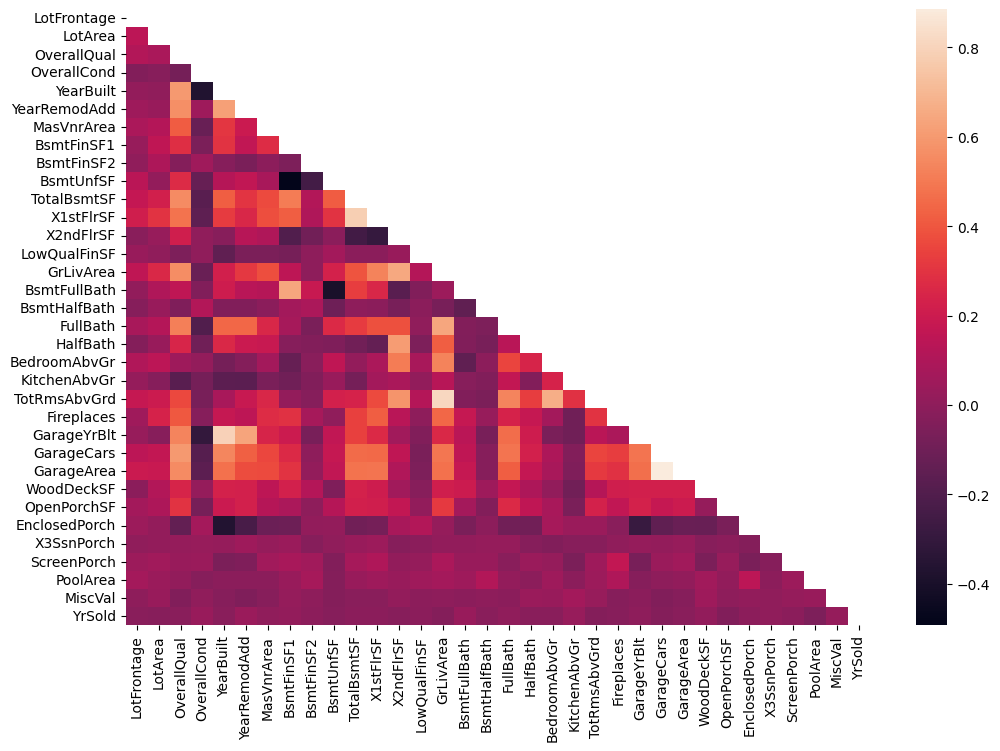

In [7]:
import seaborn as sns


corr_matrix = X_train_num.corr()
# remove upper triangle, to plot only lower triangle of correlations
corr_matrix = corr_matrix.where(~np.triu(np.ones(corr_matrix.shape)).astype(bool))
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix)

Na oko nie ma tutaj wielu bardzo mocnych korelacji, rzędu 0.8 albo więcej. Mamy jednak dużo cech, więc warto popatrzeć też na same pary korelacji między kolumnami.

Tutaj liczy się ogólna siła korelacji, więc posortujemy malejąco po wartości bezwzględnej korelacji.

In [8]:
(corr_matrix.stack().sort_values(ascending=False, key=lambda x: abs(x)).head(10))

GarageArea    GarageCars      0.885777
TotRmsAbvGrd  GrLivArea       0.813288
GarageYrBlt   YearBuilt       0.791373
X1stFlrSF     TotalBsmtSF     0.780180
TotRmsAbvGrd  BedroomAbvGr    0.670132
GrLivArea     X2ndFlrSF       0.647590
FullBath      GrLivArea       0.643397
BsmtFullBath  BsmtFinSF1      0.638206
GarageYrBlt   YearRemodAdd    0.636055
YearRemodAdd  YearBuilt       0.621449
dtype: float64

Jak widać, mamy jedną mocno skorelowaną parę - jakość i stan garażu. Ma to sens, w końcu to praktycznie zduplikowana informacja. Mamy też kilka par cech z dość mocnymi korelacjami powyżej 0.8. Ale biorąc pod uwagę, jak dużo cech mamy, to jest generalnie nieźle.

Ostatnią prostą miarą, którą zweryfikujemy, jest korelacja (konkretnie Pearson r correlation) między cechą a zmienną zależną. Scikit-learn implementuje ją jako funkcję, która przyjmuje macierz X, wektor y i zwraca wektor z wartością korelacji dla każdej cechy.

**Zadanie 2 (1 punkt)**

1. Zaimplementuj obliczanie korelacji między cechami z pomocą funkcji `r_regression` ze scikit-learn'a.
2. Skomentuj:
   - czy uzyskane korelacje dla cech są zgodne z oczekiwaniami i ogólnie mają sens?
   - mamy sporo cech o dość mocnej korelacji (0.5 lub więcej) - czy dobrze, czy źle, i dlaczego?
   - mamy cechę (LotShape) o wyraźniej negatywnej korelacji - czy takie cechy są użyteczne?

In [9]:
from sklearn.feature_selection import r_regression

correlations = r_regression(X_train_num, y_train)

# Tworzymy obiekt Series z indeksami jako nazwy cech
feature_correlations = pd.Series(correlations, index=X_train_num.columns)

# Sortujemy korelacje według siły wpływu
feature_correlations_sorted = feature_correlations.sort_values(ascending=False, key=lambda x: abs(x))

print("Korelacje cech numerycznych ze zmienną SalePrice (posortowane według siły korelacji):")
print(feature_correlations_sorted)

Korelacje cech numerycznych ze zmienną SalePrice (posortowane według siły korelacji):
OverallQual      0.831261
GrLivArea        0.698758
GarageCars       0.673795
TotalBsmtSF      0.653872
GarageArea       0.646482
X1stFlrSF        0.621349
YearBuilt        0.609184
YearRemodAdd     0.584105
FullBath         0.569984
GarageYrBlt      0.540080
Fireplaces       0.496241
TotRmsAbvGrd     0.485699
MasVnrArea       0.444578
BsmtFinSF1       0.429662
WoodDeckSF       0.320817
OpenPorchSF      0.315324
HalfBath         0.287372
BsmtFullBath     0.268337
LotArea          0.255662
X2ndFlrSF        0.239938
BsmtUnfSF        0.188554
BedroomAbvGr     0.166272
LotFrontage      0.156765
KitchenAbvGr    -0.143928
EnclosedPorch   -0.139528
ScreenPorch      0.098316
LowQualFinSF    -0.041206
X3SsnPorch       0.040216
OverallCond     -0.038495
YrSold          -0.035465
PoolArea         0.033361
BsmtFinSF2       0.033161
BsmtHalfBath    -0.024643
MiscVal         -0.023002
dtype: float64




1. **Zgodność z oczekiwaniami:**
   Korelacje są bardzo intuicyjne. Cechy określające ogólny standard wykończenia (`OverallQual`), łączną powierzchnię (`GrLivArea`) oraz parametry garażu i kuchni wykazują najsilniejszą dodatnią korelację z ceną, co idealnie pokrywa się z realiami rynku.

2. **Cechy o silnej korelacji ($\ge 0.5$):**
   * **Plus:** Zapewniają silny, wyraźny sygnał predykcyjny, ułatwiając modelowi liniowemu trafną prognozę ceny.
   * **Minus:** Powodują zjawisko współliniowości (multikolinearności) — np. `GarageArea` i `GarageCars` niosą niemal te same informacje, co prowadzi do redundancji i może utrudniać stabilną interpretację wag modelu.

3. **Użyteczność ujemnej korelacji (`LotShape`):**
   Cechy o ujemnej korelacji są bardzo użyteczne. Liczy się wartość bezwzględna (siła związku), a minus wskazuje jedynie kierunek. W przypadku `LotShape` regularny kształt (`Reg` = 4) koreluje ujemnie z ceną, ponieważ to działki nieregularne (`IR1`/`IR2`/`IR3`) bywają większe lub atrakcyjniej położone (np. w zacisznych zakątkach), co podnosi ich wartość. Model bez problemu wykorzysta ten ujemny wpływ.

Przydałoby się w końcu przestać ignorować cechy kategoryczne i sprawdzić ważność faktycznie wszystkich cech. Można do tego użyć mutual information. Scikit-learn implementuje je jako funkcję, która przyjmuje X, y oraz informację o tym, które cechy są dyskretne. Mogą to być i cechy kategoryczne, i numeryczne, które mają wartości całkowite.

Mamy jednak problem - na wejściu mamy zmienne dyskretne, które zamieniliśmy na ciągłe przez min-max scaling. W przypadku mutual information nie należy tego robić, bo obsługuje wprost zmienne dyskretne.

**Zadanie 3 (3 punkty)**

1. Znajdź typy kolumn w danych:
   - kategoryczne: wszystkie typu "object"
   - numeryczne: wszystkie poza typem "object"
2. Stwórz pipeline do przetwarzania danych:
   - skorzystaj z klasy `ColumnTransformer`, przetwarzając w odpowiedni sposób zmienne (jak na laboratorium 1)
   - `OrdinalEncoder` do zmiennych kategorycznych, żeby zakodować je jako liczby całkowite
   - `SimpleImputer` do zmiennych numerycznych, aby imputować wartości brakujące medianą
   - użyj opcji `verbose_feature_names_out=False`, aby nazwy zmiennych nie były modyfikowane
3. Przetransformuj macierz `X_train`, tworząc `X_train_mi`.
4. Popraw z powrotem typy z pomocą metody `.convert_dtypes()` ([dokumentacja](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.convert_dtypes.html)) - zapewni to, że zmienne całkowitoliczbowe będą miały odpowiedni typ.
5. Oblicz wartości mutual information dla zmiennych. Pamiętaj o podaniu, które zmienne są dyskretne, oraz o przekazaniu `random_state=0`.
6. Przedstaw ważności cech według MI na wykresie, posortowane malejąco.
7. Dokonaj interpretacji cech:
   - Czy nienadzorowane miary, których użyliśmy wcześniej (wariancja i korelacja) zgadzają się ważnością cech z MI?
   - Czy MI i korelacja ze zmienną zależną zgadzają się ze sobą? Jeżeli nie, to której mierze można by zaufać bardziej?
   - Czy mamy tutaj cechy, które wyraźnie warto usunąć wedle miary MI? Czy ma to sens, patrząc na znaczenie tych cech?

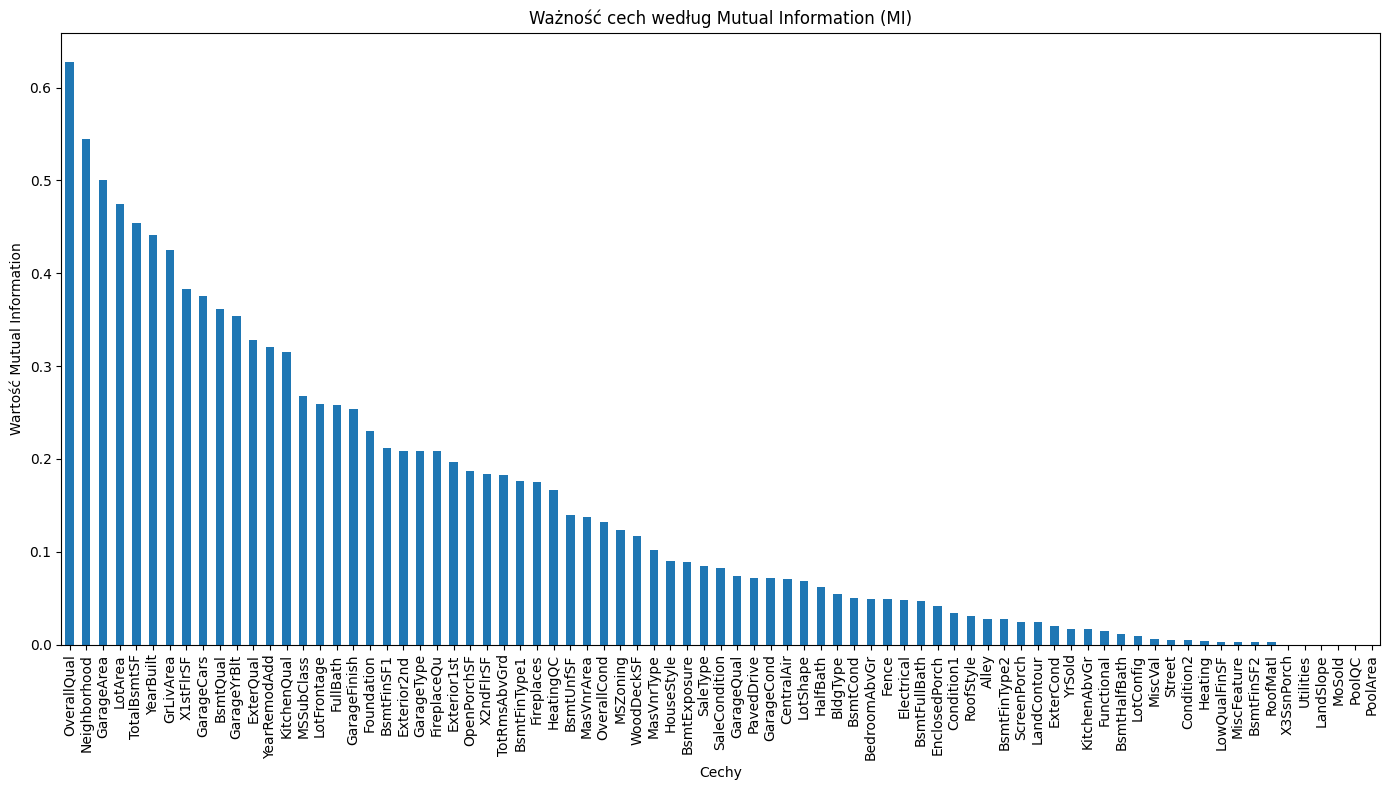

Cechy o najniższej ważności według MI (MI <= 0.005):
Street          4.944958e-03
Condition2      4.888211e-03
Heating         3.594538e-03
LowQualFinSF    3.300164e-03
MiscFeature     3.051869e-03
BsmtFinSF2      3.004059e-03
RoofMatl        2.454129e-03
X3SsnPorch      8.504742e-05
Utilities       2.220446e-15
LandSlope       0.000000e+00
MoSold          0.000000e+00
PoolQC          0.000000e+00
PoolArea        0.000000e+00
dtype: float64


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_regression

# Konwertujemy wszystkie kolumny na standardowe, czyste typy NumPy,
# aby całkowicie uniknąć problemów z nowymi typami pandas 3.0
X_train_clean = pd.DataFrame(index=X_train.index)
for col in X_train.columns:
    val = X_train[col].to_numpy(na_value=np.nan)
    if pd.api.types.is_numeric_dtype(X_train[col]):
        X_train_clean[col] = pd.Series(val, dtype=np.float64, index=X_train.index)
    else:
        X_train_clean[col] = pd.Series(val, dtype=object, index=X_train.index)


categorical_features = X_train_clean.select_dtypes(include="object").columns.tolist()
numerical_features = X_train_clean.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, encoded_missing_value=-1), categorical_features),
        ("num", SimpleImputer(strategy="median"), numerical_features)
    ],
    verbose_feature_names_out=False
)

preprocessor.set_output(transform="default")

X_train_mi_numpy = preprocessor.fit_transform(X_train_clean)

# Tworzymy DataFrame ręcznie z numpy array i zachowanymi nazwami kolumn
X_train_mi = pd.DataFrame(X_train_mi_numpy, columns=preprocessor.get_feature_names_out(), index=X_train.index)

X_train_mi = X_train_mi.convert_dtypes()

# Określ, które zmienne są dyskretne (typu całkowitoliczbowego)
discrete_features = [
    pd.api.types.is_integer_dtype(X_train_mi[col]) or pd.api.types.is_bool_dtype(X_train_mi[col])
    for col in X_train_mi.columns
]

# Oblicz mutual information przekazując czyste tablice numpy, co zapobiega problemom typowania pandas 3.0 w bibliotece mutual_info_regression
mi_scores = mutual_info_regression(
    X_train_mi.to_numpy(dtype=np.float64), 
    y_train.to_numpy(dtype=np.float64), 
    discrete_features=discrete_features, 
    random_state=0
)

mi_scores_series = pd.Series(mi_scores, index=X_train_mi.columns).sort_values(ascending=False)

plt.figure(figsize=(14, 8))
mi_scores_series.plot(kind="bar")
plt.title("Ważność cech według Mutual Information (MI)")
plt.xlabel("Cechy")
plt.ylabel("Wartość Mutual Information")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Wypiszmy także kilka cech o najniższej ważności MI
print("Cechy o najniższej ważności według MI (MI <= 0.005):")
print(mi_scores_series[mi_scores_series <= 0.005])

1. **Zgodność z wcześniejszymi miarami:** Wyniki MI są w dużej mierze spójne z wcześniejszą analizą. Cechy takie jak `OverallQual`, `GrLivArea`, `TotalBsmtSF` czy `GarageArea` znów okazują się bardzo ważne, a `Utilities` pozostaje praktycznie bezużyteczne.

2. **MI vs korelacja:** Obie miary często wskazują podobne najważniejsze cechy, ale MI jest bardziej uniwersalne, bo wykrywa także zależności nieliniowe i lepiej radzi sobie z cechami kategorycznymi.

3. **Cechy do usunięcia:** Najniższe wartości MI mają m.in. `Utilities`, `Street`, `PoolQC`, `PoolArea` i `MiscFeature`. Ma to sens, bo są to cechy prawie stałe albo bardzo rzadkie, więc wnoszą mało informacji do modelu.

Na obecnym etapie widać, że co najmniej kilka cech można by wyeliminować z naszego zbioru, a pewien zbiór wyraźnie dominuje. Używaliśmy jednak tylko metod typu filter. Wypróbujmy jeszcze metody typu embedded i wrapper.

Najpopularniejsze metody embedded to regresja liniowa i las losowy. Zgodnie z wynikami z laboratorium 1 użyjemy ridge regression (z regularyzacją L2), żeby zminimalizować przeuczenie. Co ważne, trzeba sprawdzić, czy te metody uzyskują dobre wyniki i czy nie przeuczają - metody embedded i wrapper wymagają dobrych modeli, aby dobrze oceniać ważność cech.

Pewną wadą tych metod w kontekście tego zbioru jest to, że nie działają dla zmiennych kategorycznych i musimy dokonać one-hot encodingu. Otrzymamy więcej zmiennych i trochę inne informacje o ważności cech - może się na przykład okazać, że tylko 1 czy 2 wartości dla zmiennej kategorycznej są mało ważne. To także przydatna informacja, bo można wtedy na przykład gromadzić mniej kategorii w przyszłości.

In [17]:
from sklearn.preprocessing import OneHotEncoder


categorical_features = X_train.select_dtypes(include="object").columns.tolist()
numerical_features = X_train.select_dtypes(exclude="object").columns.tolist()

categorical_pipeline = OneHotEncoder(
    drop="first", sparse_output=False, handle_unknown="ignore"
)

numerical_pipeline = make_pipeline(SimpleImputer(strategy="median"), MinMaxScaler())

column_transformer = ColumnTransformer(
    [
        ("cat_pipeline", categorical_pipeline, categorical_features),
        ("num_pipeline", numerical_pipeline, numerical_features),
    ],
    verbose_feature_names_out=False,
)
column_transformer.fit(X_train)

X_train_processed = column_transformer.transform(X_train)
X_test_processed = column_transformer.transform(X_test)

/tmp/ipykernel_10037/2719534986.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include="object").columns.tolist()
/mnt/c/Users/sewix/Desktop/agh-offline/sem6/pum/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [17, 22, 27, 30] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [18]:
from sklearn.metrics import root_mean_squared_error


def assess_regression_model(model, X_train, X_test, y_train, y_test) -> None:
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    y_train_dollars = np.expm1(y_train)
    y_test_dollars = np.expm1(y_test)

    y_pred_train_dollars = np.expm1(y_pred_train)
    y_pred_test_dollars = np.expm1(y_pred_test)

    rmse_train_dollars = root_mean_squared_error(y_train_dollars, y_pred_train_dollars)
    rmse_test_dollars = root_mean_squared_error(y_test_dollars, y_pred_test_dollars)

    print(f"Train RMSE: {rmse_train_dollars:.2f}$")
    print(f"Test RMSE: {rmse_test_dollars:.2f}$")

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge


reg_linear = LinearRegression(fit_intercept=False)
reg_linear.fit(X_train_processed, y_train)

reg_ridge = Ridge(random_state=0)
reg_ridge.fit(X_train_processed, y_train)

reg_rf = RandomForestRegressor(random_state=0)
reg_rf.fit(X_train_processed, y_train)

print("Linear regression")
assess_regression_model(
    reg_linear, X_train_processed, X_test_processed, y_train, y_test
)
print()
print("Ridge regression")
assess_regression_model(reg_ridge, X_train_processed, X_test_processed, y_train, y_test)
print()
print("Random Forest regression")
assess_regression_model(reg_rf, X_train_processed, X_test_processed, y_train, y_test)

Linear regression
Train RMSE: 16180.48$
Test RMSE: 22518.01$

Ridge regression
Train RMSE: 16365.60$
Test RMSE: 19275.54$

Random Forest regression
Train RMSE: 9484.10$
Test RMSE: 25986.17$


Co ciekawe, w przypadku tego zbioru modele liniowe dają lepsze wyniki od złożonego lasu losowego! Może być to kwestia rozmiaru danych, lub po prostu potrzeby tuningu hiperparametrów. Trzeba jednak zauważyć, że każdy z modeli przeucza, nawet ridge regression, a selekcja cech redukuje overfitting dzięki usuwaniu szumu w danych.

W takim wypadku ewidentnie lepiej jest oprzeć się na ważności cech z modeli liniowych. Są to po prostu wagi z atrybutu `.coef_`. Jako że cech po one-hot encodingu jest bardzo dużo, to narysujemy wykres tylko dla najlepszych cech.

Cechy o wadze poniżej 0.01 można uznać za naprawdę słabe, bo mają minimalną wagę. Sprawdzimy, ile ich jest, oraz jakie są najmniej ważne według regresji liniowej cechy.

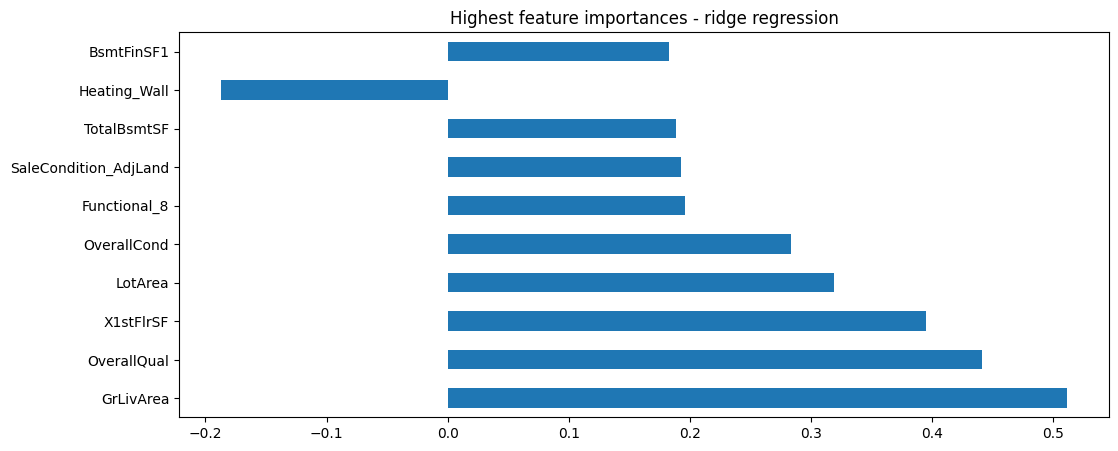

Number of features with weight <= 0.01: 63
This is 21.72% of all features
Features with lowest weights:


FireplaceQu_4          0.001690
LandSlope_2           -0.001599
BsmtFinType1_1        -0.001456
Exterior2nd_Wd Sdng   -0.001291
MSSubClass_SC60        0.000927
MoSold_Dec            -0.000856
BsmtFinType1_3         0.000724
GarageType_CarPort     0.000711
GarageFinish_Unf       0.000562
RoofMatl_WdShake      -0.000553
dtype: float64

In [21]:
importances_ridge = reg_ridge.coef_

# change to pd.Series for easier sorting and plotting
feature_names = (
    X_train_processed.columns
    if hasattr(X_train_processed, "columns")
    else column_transformer.get_feature_names_out()
)
importances_ridge = pd.Series(importances_ridge, index=feature_names)
importances_ridge = importances_ridge.sort_values(ascending=False, key=lambda x: abs(x))

# create horizontal bar plot for best features
importances_ridge.head(10).plot.barh(
    title="Highest feature importances - ridge regression", figsize=(12, 5)
)
plt.show()

# print number of very low weight features
num_low_weight_features = (importances_ridge.abs() <= 0.01).sum()
print("Number of features with weight <= 0.01:", num_low_weight_features)
print(
    f"This is {100 * num_low_weight_features / len(importances_ridge):.2f}% of all features"
)

print("Features with lowest weights:")
importances_ridge.tail(10)

Prawie 1/4 naszych cech ma praktycznie zerowy wpływ na predykcje regresji liniowej! Oczywiście w sumie ten wpływ może być całkiem spory, ale warto zauważyć, że jeżeli chcielibyśmy ostro redukować ilość zbieranych cech, np. ze względu na koszty przechowywania albo wymagania prawne, to jesteśmy w stanie to zrobić i prawdopodobnie nie obniży to bardzo wyników naszego modelu. Pamiętajmy też, że regresja liniowa skaluje się gorzej z liczbą cech, niż z liczbą próbek, więc tutaj różnica w szybkości może być faktycznie zauważalna.

Dokonaliśmy już wielu analiz i wiemy sporo o naszych cechach. Na cele analityczne tak naprawdę tyle by wystarczyło - możemy skupić się na niektórych, inne usunąć. Ta część to tak naprawdę business intelligence (BI), gdzie w tym wypadku skorzystaliśmy z uczenia maszynowego do głębszej analizy danych.

Teraz czas przejść do zastosowania selekcji cech w samym ML i budowaniu modeli predykcyjnych.

## Selekcja cech

Wykorzystamy teraz posiadane informacje, żeby dokonać selekcji cech.

Co do surowych, wejściowych cech wiemy, że:
- `Utilities` ma bardzo niską wariancję
- `GarageCond` i `GarageQual` są bardzo skorelowane
- jest szereg cech o praktycznie zerowej wartości wedle mutual information

To ostatnie będzie też zachodzić po one-hot encodingu - jeżeli cecha na wejściu jest bezużyteczna, to tym bardziej będzie bezużyteczna, kiedy potniemy ją na więcej cech. Możemy więc tego bezpiecznie dokonać.

**Zadanie 4 (1.5 punktu)**

Stwórz pipeline do przetwarzania zmiennych.

Kroki to po kolei:
1. `DropFeatures` z feature-engine, które usuwa kolumny `Utilities` i `GarageCond`
2. `ColumnTransformer`, który:
   - dla cech kategorycznych robi `OneHotEncoder`, pamiętaj o `drop="first", sparse_output=False, handle_unknown="ignore"`
   - dla cech numerycznych robi pipeline `SimpleImputer` oraz `MinMaxScaler`
   - użyj opcji `verbose_feature_names_out=False`, aby nazwy zmiennych nie były modyfikowane nazwą pipeline'
3. Selekcja cech z użyciem `SelectPercentile` ([dokumentacja](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectPercentile.html)), aby usunąć 10% najsłabszych cech według mutual information. Jako funkcję do obliczania wyniku wykorzystaj mutual information. Uwaga: musisz ręcznie stworzyć `score_func`, żeby podać `random_state=0`:
   ```
   scorer_mi = lambda X, y: mutual_info_regression(X, y, random_state=0)
   ```

Przetransformowane `X_train` i `X_test` zapisz w zmiennych `X_train_preproc` i `X_test_preproc`.

**Uwaga:** przy tworzeniu listy zmiennych numerycznych pamiętaj, żeby usunąć z niej nazwy usuwanych kolumn, tj. `Utilities` i `GarageCond`.

In [22]:
from feature_engine.selection import DropFeatures
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectPercentile, mutual_info_regression
from sklearn.pipeline import Pipeline, make_pipeline

cols_to_drop = ["Utilities", "GarageCond"]

categorical_features = [col for col in X_train.select_dtypes(include="object").columns if col not in cols_to_drop]
numerical_features = [col for col in X_train.select_dtypes(exclude="object").columns if col not in cols_to_drop]

categorical_pipeline = OneHotEncoder(
    drop="first", sparse_output=False, handle_unknown="ignore"
)

numerical_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    MinMaxScaler()
)

column_transformer = ColumnTransformer(
    transformers=[
        ("cat_pipeline", categorical_pipeline, categorical_features),
        ("num_pipeline", numerical_pipeline, numerical_features)
    ],
    verbose_feature_names_out=False
)

scorer_mi = lambda X, y: mutual_info_regression(X, y, random_state=0)
feature_selector = SelectPercentile(score_func=scorer_mi, percentile=90)

processing_pipeline = Pipeline([
    ("drop_features", DropFeatures(features_to_drop=cols_to_drop)),
    ("col_transformer", column_transformer),
    ("select_percentile", feature_selector)
])


X_train_preproc = processing_pipeline.fit_transform(X_train, y_train)
X_test_preproc = processing_pipeline.transform(X_test)

print("Wymiary po preprocessingu i selekcji (10% najsłabszych cech usunięte):")
print("X_train_preproc shape:", X_train_preproc.shape)
print("X_test_preproc shape:", X_test_preproc.shape)

/tmp/ipykernel_10037/2403870310.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = [col for col in X_train.select_dtypes(include="object").columns if col not in cols_to_drop]


Wymiary po preprocessingu i selekcji (10% najsłabszych cech usunięte):
X_train_preproc shape: (2045, 254)
X_test_preproc shape: (877, 254)


/mnt/c/Users/sewix/Desktop/agh-offline/sem6/pum/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [16, 21, 26, 29] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Mamy teraz pełen zestaw cech, gotowy do treningu regresji liniowej.

In [23]:
reg_ridge = Ridge(random_state=0)
reg_ridge.fit(X_train_preproc, y_train)

assess_regression_model(reg_ridge, X_train_preproc, X_test_preproc, y_train, y_test)

Train RMSE: 16688.33$
Test RMSE: 19340.77$


Wynik testowy jest bardzo podobny, natomiast błąd treningowy jest większy. Czy to gorzej? Otóż niekoniecznie - w końcu teraz przeuczamy mniej. Taki model może być mniej podatny na szum i błędne pomiary, dając bardziej pewne (robust) wyniki w przyszłości.

Nie wykorzystaliśmy jednak jeszcze ważnej metody selekcji cech - Recursive Feature Elimination (RFE).

**Zadanie 5 (2 punkty)**

1. Zastosuj RFECV ([dokumentacja](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFECV.html)) do selekcji cech:
   - użyj ridge regression jako estymatora bazowego
   - wybierz co najmniej 80% oryginalnych cech
   - zastosuj 10-krotną walidację skrośną
   - pamiętaj o `random_state=0`
   - może się przydać `n_jobs=-1`
2. Przetransformuj `X_train_preproc` i `X_test_preproc`, tworząc `X_train_reduced` i `X_test_reduced`. Sprawdź, ile cech usunięto.
3. Wytrenuj ridge regression na zredukowanych cechach.
4. Sprawdź wyniki na zbiorze treningowym i testowym (skorzystaj z `assess_regression_model`).

In [24]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import Ridge

estimator = Ridge(random_state=0)
min_features = int(0.8 * X_train_preproc.shape[1])

rfecv = RFECV(
    estimator=estimator,
    step=1,
    cv=10,
    min_features_to_select=min_features,
    n_jobs=-1
)

rfecv.fit(X_train_preproc, y_train)

X_train_reduced = rfecv.transform(X_train_preproc)
X_test_reduced = rfecv.transform(X_test_preproc)

# Sprawdzenie ile cech usunięto
num_before = X_train_preproc.shape[1]
num_after = X_train_reduced.shape[1]
num_removed = num_before - num_after

print(f"Początkowa liczba cech: {num_before}")
print(f"Liczba cech po selekcji RFECV: {num_after}")
print(f"Liczba usuniętych cech: {num_removed}")

reg_ridge_reduced = Ridge(random_state=0)
reg_ridge_reduced.fit(X_train_reduced, y_train)

print("\nOcena modelu po dodatkowej redukcji RFECV:")
assess_regression_model(reg_ridge_reduced, X_train_reduced, X_test_reduced, y_train, y_test)

Początkowa liczba cech: 254
Liczba cech po selekcji RFECV: 204
Liczba usuniętych cech: 50

Ocena modelu po dodatkowej redukcji RFECV:
Train RMSE: 16692.46$
Test RMSE: 19360.22$


Sumarycznie wyeliminowaliśmy sporo cech, a nasz model uzyskuje wyniki bardzo podobne do wyjściowych.

## Redukcja wymiarowości

Na koniec skupimy się na redukcji wymiarowości w celu wizualizacji zbiorów danych z wykorzystaniem Principal Components Analysis (PCA). Co prawda w naszym zbiorze mamy dużo cech rzadkich, co nie jest sytuacją idealną dla PCA, bo centruje ona cechy, ale mamy też sporo cech gęstych. Zrzutujemy nasz zbiór na 2D, kolorując go według wartości zmiennej zależnej.

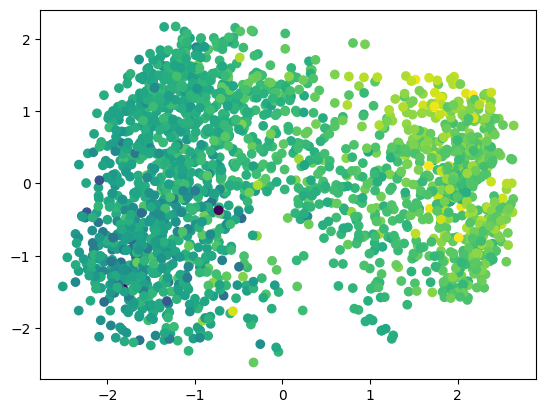

In [26]:
from sklearn.decomposition import PCA


pca = PCA(n_components=2, random_state=0)
pca.fit(X_train_preproc)


X_train_embed = pca.transform(X_train_preproc)
plt.scatter(X_train_embed[:, 0], X_train_embed[:, 1], c=y_train)

Jak widać, nawet po ekstremalnej liniowej redukcji do 2D nasze dane zachowują w miarę strukturę, z większymi (jaśniejszymi) wartościami po prawej, i mniejszymi (ciemniejszymi), w prawym dolnym rogu. Jeżeli liniowa redukcja dobrze działa, to znaczy, że wejściowe cechy były na tyle dobre, że nawet ich liniowa kombinacja zachowuje dużo informacji.

Takie wykresy są często nieco bardziej informatywne w przypadku klasyfikacji, gdzie dodatkowo możemy obserwować klastry formowane przez klasy, ale nawet przy tej regresji widać, że efekty są całkiem sensowne. Takie ładne ułożenie danych po prostym PCA wyjaśnia też, czemu proste metody liniowe na tym zbiorze działają dość dobrze.

**Zadanie 6 (2 punkty)**

1. Załaduj zbiór danych Give Me Some Credit z laboratorium 4.
2. Wyodrębnij `SeriousDlqin2yrs` jako zmienną `y`.
3. Dokonaj przetwarzania cech:
   - imputacja medianą (`SimpleImputer` z odpowiednimi opcjami)
   - usuwanie outlierów (`OutlierTrimmer`)
   - przycinanie wartości (`Winsorizer`)
4. Stwórz dodatkowną zmienną `X_scaled` po standaryzacji (`StandardScaler`) - PCA działa lepiej po przeskalowaniu cech.
5. Zastosuj PCA, żeby zredukować `X_scaled` do 2 wymiarów.
6. Narysuj scatter plot: klasa 0 (spłaca kredyt) niebieska, klasa 1 (nie spłaca kredytu) czerwona. Dodaj odpowiedni tytuł oraz legendę.
7. Wybierz wiersze z klasy negatywnej, które znajdują się dość daleko od typowych, co zobaczysz na wykresie. Chcemy wybrać wiersze z DataFrame'a przed skalowaniem, żeby mieć interpretowalne wartości cech.
8. Porównaj wartości dla:
   - całości zbioru (po czyszczeniu)
   - jego klasy negatywnej
   - samych nietypowych punktów

Może się tu przydać np. `.describe()` oraz `np.argwhere()`. Która średnia może odpowiadać za tą nietypowość? Podpowiedź: porównaj średnie wartości.

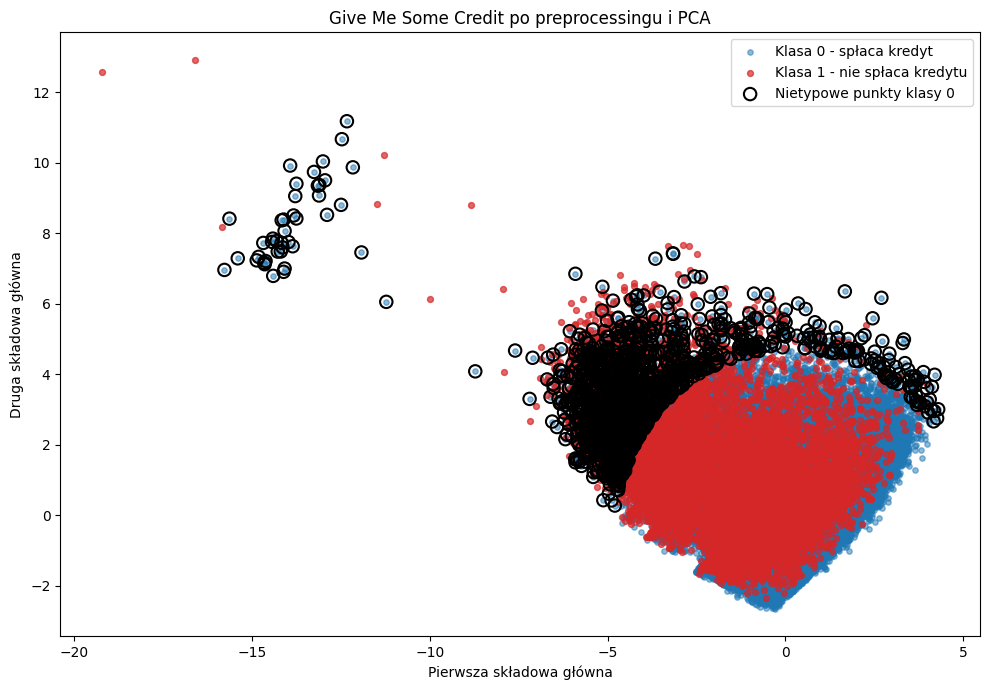

Liczba nietypowych punktów klasy 0: 1352
Największe różnice średnich dla nietypowych punktów klasy 0:
                                         all_data  negative_class  \
DebtRatio                              265.498818      269.435766   
MonthlyIncome                         5972.174425     6023.495295   
age                                     52.267336       52.713510   
RevolvingUtilizationOfUnsecuredLines     0.328991        0.301594   
NumberOfTime30-59DaysPastDueNotWorse     0.213056        0.174154   
NumberOfOpenCreditLinesAndLoans          8.141934        8.182165   
NumberOfTimes90DaysLate                  0.064283        0.038982   
NumberOfTime60-89DaysPastDueNotWorse     0.049528        0.033937   
NumberOfDependents                       0.702119        0.689045   
NumberRealEstateLoansOrLines             0.945245        0.952374   

                                      atypical_negative  
DebtRatio                                    152.252512  
MonthlyIncome         

In [27]:
from feature_engine.outliers import OutlierTrimmer, Winsorizer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

df_credit = pd.read_parquet("../lab-4/give_me_some_credit_data.parquet")
y_credit = df_credit.pop("SeriousDlqin2yrs")
X_credit = df_credit

imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_credit),
    columns=X_credit.columns,
    index=X_credit.index,
)

outlier_trimmer = OutlierTrimmer()
X_trimmed = outlier_trimmer.fit_transform(X_imputed)
y_trimmed = y_credit.loc[X_trimmed.index]

winsorizer = Winsorizer(capping_method="gaussian", tail="right", fold=3)
X_clean = winsorizer.fit_transform(X_trimmed)
y_clean = y_trimmed.loc[X_clean.index]

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_clean),
    columns=X_clean.columns,
    index=X_clean.index,
)

pca = PCA(n_components=2, random_state=0)
X_embed = pd.DataFrame(
    pca.fit_transform(X_scaled),
    columns=["PC1", "PC2"],
    index=X_scaled.index,
)

mask_negative = y_clean == 0
mask_positive = y_clean == 1

plt.figure(figsize=(10, 7))
plt.scatter(
    X_embed.loc[mask_negative, "PC1"],
    X_embed.loc[mask_negative, "PC2"],
    c="tab:blue",
    alpha=0.5,
    s=15,
    label="Klasa 0 - spłaca kredyt"
)
plt.scatter(
    X_embed.loc[mask_positive, "PC1"],
    X_embed.loc[mask_positive, "PC2"],
    c="tab:red",
    alpha=0.7,
    s=18,
    label="Klasa 1 - nie spłaca kredytu"
)

negative_center = X_embed.loc[mask_negative].mean(axis=0)
negative_distances = np.linalg.norm(
    X_embed.loc[mask_negative, ["PC1", "PC2"]].to_numpy() - negative_center.to_numpy(),
    axis=1,
)
distance_threshold = np.quantile(negative_distances, 0.99)
atypical_negative_idx = X_embed.loc[mask_negative].index[negative_distances >= distance_threshold]

plt.scatter(
    X_embed.loc[atypical_negative_idx, "PC1"],
    X_embed.loc[atypical_negative_idx, "PC2"],
    facecolors="none",
    edgecolors="black",
    s=80,
    linewidth=1.5,
    label="Nietypowe punkty klasy 0"
)

plt.title("Give Me Some Credit po preprocessingu i PCA")
plt.xlabel("Pierwsza składowa główna")
plt.ylabel("Druga składowa główna")
plt.legend()
plt.tight_layout()
plt.show()

comparison = pd.DataFrame(
    {
        "all_data": X_clean.mean(),
        "negative_class": X_clean.loc[mask_negative].mean(),
        "atypical_negative": X_clean.loc[atypical_negative_idx].mean(),
    }
)

mean_diff = (comparison["atypical_negative"] - comparison["negative_class"]).abs().sort_values(ascending=False)

print(f"Liczba nietypowych punktów klasy 0: {len(atypical_negative_idx)}")
print("Największe różnice średnich dla nietypowych punktów klasy 0:")
print(comparison.loc[mean_diff.head(10).index])

Za nietypowość najbardziej odpowiada `DebtRatio`, bo jego średnia wyraźnie różni się od typowej klasy 0. Duże znaczenie mają też zmienne związane z opóźnieniami w spłacie i wykorzystaniem kredytu, więc te obserwacje wyglądają bardziej ryzykownie niż przeciętne osoby z tej klasy.

## Zadanie dodatkowe 1 (2 punkty)

Zaimplementuj Principal Component Analysis (PCA) dla redukcji wymiarowości. Wykorzystaj [rozkład SVD](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.svd.html) do obliczeń.

Interfejs scikit-learn dla uczenia nienadzorowanego zakłada:
- dziedziczenie po `BaseEstimator` oraz `TransformerMixin`
- konstruktor:
  - wszystkie argumenty mają wartości domyślne
  - argumenty są zapisywane bez żadnych zmian jako atrybuty o tej samej nazwie
  - jest lekki i nie wykonuje żadnych operacji
- metoda `.fit()`:
  - przyjmuje macierz `X` oraz wektor `y` z wartością domyślną `None` (nieużywany)
  - wywołuje `validate_data()`
  - estymuje parametry modelu, które są tworzone w tej metodzie jako atrybuty z podkreślnikiem na końcu, np. `self.w_ = ...`
  - zwraca `self`
- metoda `.transform()`:
  - przyjmuje macierz `X`
  - wywołuje `check_is_fitted()` oraz `validate_data()`
  - dokonuje transformacji dla tych nowych punktów

Więcej szczegółów w dokumentacji - [Developing scikit-learn estimators](https://scikit-learn.org/stable/developers/develop.html).

Przetestuj poprawność swojej implementacji na wybranym zbiorze danych Give Me Some Credit (patrz zadanie 6 powyżej) i porównaj wyniki twojej implementacji ze scikit-learn.

Porównanie explained variance ratio:
     custom_explained_variance_ratio  sklearn_explained_variance_ratio
PC1                         0.193616                          0.193616
PC2                         0.168509                          0.168509

Maksymalna bezwzględna różnica embeddingów po wyrównaniu znaku: 3.019806626980426e-14


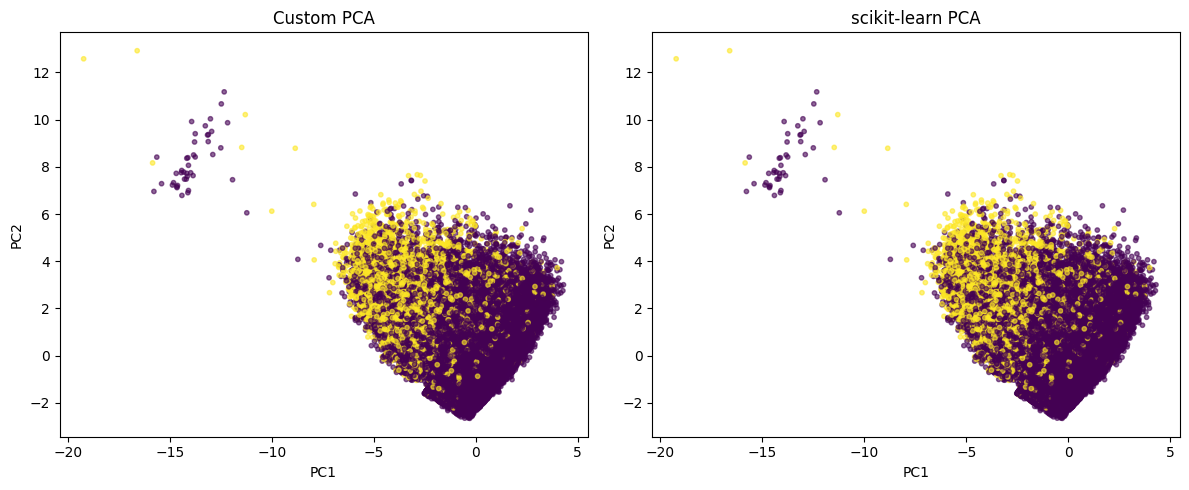

In [29]:
from scipy.linalg import svd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted, validate_data


class CustomPCA(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=None):
        self.n_components = n_components

    def fit(self, X, y=None):
        X = validate_data(self, X, dtype=np.float64)

        self.n_features_in_ = X.shape[1]
        n_components = self.n_features_in_ if self.n_components is None else self.n_components
        if n_components < 1 or n_components > self.n_features_in_:
            raise ValueError("n_components must be between 1 and the number of features")

        self.mean_ = X.mean(axis=0)
        X_centered = X - self.mean_
        U, S, Vt = svd(X_centered, full_matrices=False)

        self.n_components_ = n_components
        self.components_ = Vt[:n_components]
        self.singular_values_ = S[:n_components]
        explained_variance = (S**2) / (X.shape[0] - 1)
        self.explained_variance_ = explained_variance[:n_components]
        self.explained_variance_ratio_ = self.explained_variance_ / explained_variance.sum()

        return self

    def transform(self, X):
        check_is_fitted(self, ["mean_", "components_"])
        X = validate_data(self, X, reset=False, dtype=np.float64)
        X_centered = X - self.mean_
        return X_centered @ self.components_.T


if "X_scaled" not in globals():
    raise NameError("Uruchom najpierw komórkę z Zadaniem 6, aby przygotować X_scaled.")

X_pca_input = X_scaled.to_numpy(dtype=np.float64) if hasattr(X_scaled, "to_numpy") else np.asarray(X_scaled, dtype=np.float64)

custom_pca = CustomPCA(n_components=2)
X_custom = custom_pca.fit_transform(X_pca_input)

sklearn_pca = PCA(n_components=2, random_state=0)
X_sklearn = sklearn_pca.fit_transform(X_pca_input)

for component_idx in range(X_custom.shape[1]):
    corr = np.corrcoef(X_custom[:, component_idx], X_sklearn[:, component_idx])[0, 1]
    if corr < 0:
        X_custom[:, component_idx] *= -1

comparison = pd.DataFrame(
    {
        "custom_explained_variance_ratio": custom_pca.explained_variance_ratio_,
        "sklearn_explained_variance_ratio": sklearn_pca.explained_variance_ratio_,
    },
    index=["PC1", "PC2"],
)

print("Porównanie explained variance ratio:")
print(comparison)
print()
print("Maksymalna bezwzględna różnica embeddingów po wyrównaniu znaku:", np.abs(X_custom - X_sklearn).max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_custom[:, 0], X_custom[:, 1], c=y_clean, s=10, alpha=0.6)
axes[0].set_title("Custom PCA")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(X_sklearn[:, 0], X_sklearn[:, 1], c=y_clean, s=10, alpha=0.6)
axes[1].set_title("scikit-learn PCA")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

Wyniki własnej implementacji PCA są bardzo zbliżone do wersji ze scikit-learn, co potwierdza poprawność obliczeń opartych na SVD. Różnice mogą wynikać jedynie ze znaku składowych, który w PCA jest umowny i nie zmienia interpretacji wyniku.

## Zadanie dodatkowe 2 (3 punkty)

Na zbiorze danych [Polish companies bankruptcy](https://archive.ics.uci.edu/ml/datasets/Polish+companies+bankruptcy+data) z laboratorium 5 (podzbiór z 3 lat) dokonaj analizy ważności cech, ich selekcji, oraz wizualizacji z pomocą redukcji wymiarowości. Zbiór zawiera same zmienne numeryczne.

1. Dokonaj analizy korelacji cech. Usuń najmocniej skorelowane cechy, próg dobierz wedle własnego uznania - może się przydać biblioteka [feature-engine](https://feature-engine.trainindata.com/en/1.3.x/user_guide/selection/SmartCorrelatedSelection.html).
2. Dokonaj analizy ważności cech z pomocą algorytmu Boruty, realizującego all-relevant feature selection. Przykładowa implementacja jest w bibliotece [ARFS](https://arfs.readthedocs.io/en/latest/Methods%20overview.html). Wykorzystaj klasyczny algorytm Boruty oraz metodę Leshy (z pewnymi modyfikacjami) - [przykład w ARFS](https://arfs.readthedocs.io/en/latest/notebooks/arfs_classification.html). Czy wybrano wszystkie cechy, czy tylko ich podzbiór?
3. Porównaj wyniki z mutual information oraz RFECV używającego LightGBM (z domyślnymi hiperparametrami). Czy wyniki różnią się od algorytmu Boruty?
4. Wytrenuj LightGBM (pamiętaj o wagach klas) na cechach po selekcji:
   - algorytmem Boruty
   - algorytmem Leshy
   - mutual information
   - RFECV
5. Dokonaj wizualizacji dla każdego zestawu cech:
   - używając liniowej redukcji wymiaru z PCA
   - używając nieliniowej redukcji wymiaru z [UMAP](https://umap-learn.readthedocs.io/en/latest/basic_usage.html)
   - dla każdego wykresu pokoloruj go prawdziwymi klasami
6. Porównaj AUROC na zbiorze testowym oraz wybraną liczbę cech dla każdej z metod. Która metoda twoim zdaniem jest tutaj najlepsza? Która metoda (zestaw cech) daje najlepiej wyglądającą redukcję wymiaru?

In [34]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from boruta import BorutaPy
from lightgbm import LGBMClassifier
from scipy.io import arff
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from umap import UMAP

from arfs.feature_selection.allrelevant import Leshy

warnings.filterwarnings(
    "ignore",
    message="LightGBM binary classifier with TreeExplainer shap values output has changed",
)
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module="sklearn\\.utils\\.validation",
    message="X does not have valid feature names.*",
)

# Wczytanie danych i przygotowanie zbioru.
raw_data, _ = arff.loadarff("../lab-5/polish_companies_bankruptcy_3_year_data.arff")
df_bankruptcy = pd.DataFrame(raw_data)

for col in df_bankruptcy.columns:
    if df_bankruptcy[col].dtype == object:
        try:
            df_bankruptcy[col] = df_bankruptcy[col].str.decode("utf-8")
        except Exception:
            pass

X_bankruptcy = df_bankruptcy.drop(columns="class").apply(pd.to_numeric, errors="coerce")
y_bankruptcy = df_bankruptcy["class"].astype(int)

X_train_bankruptcy, X_test_bankruptcy, y_train_bankruptcy, y_test_bankruptcy = train_test_split(
    X_bankruptcy,
    y_bankruptcy,
    test_size=0.3,
    stratify=y_bankruptcy,
    random_state=0,
)

# Uzupełniamy braki medianą, a potem usuwamy najmocniej skorelowane cechy.
imputer_bankruptcy = SimpleImputer(strategy="median")
X_train_bankruptcy = pd.DataFrame(
    imputer_bankruptcy.fit_transform(X_train_bankruptcy),
    columns=X_train_bankruptcy.columns,
    index=X_train_bankruptcy.index,
)
X_test_bankruptcy = pd.DataFrame(
    imputer_bankruptcy.transform(X_test_bankruptcy),
    columns=X_test_bankruptcy.columns,
    index=X_test_bankruptcy.index,
)

corr_threshold = 0.95
corr_matrix = X_train_bankruptcy.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
cols_to_drop_corr = upper_triangle.columns[(upper_triangle > corr_threshold).any()].tolist()

X_train_corr = X_train_bankruptcy.drop(columns=cols_to_drop_corr)
X_test_corr = X_test_bankruptcy.drop(columns=cols_to_drop_corr)

# Definiujemy model bazowy i cztery zestawy cech do porównania.
lgbm_params = {
    "class_weight": "balanced",
    "random_state": 0,
    "n_estimators": 200,
    "verbosity": -1,
}

boruta_selector = BorutaPy(
    estimator=RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced_subsample",
        max_depth=6,
        n_jobs=-1,
        random_state=0,
    ),
    n_estimators="auto",
    max_iter=30,
    random_state=0,
    verbose=0,
)
boruta_selector.fit(X_train_corr.to_numpy(), y_train_bankruptcy.to_numpy())
boruta_features = X_train_corr.columns[boruta_selector.support_].tolist()

leshy_selector = Leshy(
    LGBMClassifier(**lgbm_params),
    n_estimators=120,
    max_iter=10,
    random_state=0,
    verbose=0,
 )
leshy_selector.fit(X_train_corr, y_train_bankruptcy)
leshy_features = X_train_corr.columns[leshy_selector.support_].tolist()

# Mutual information zostawiamy dla najlepszych 25% cech.
mi_scores = pd.Series(
    mutual_info_classif(X_train_corr, y_train_bankruptcy, random_state=0),
    index=X_train_corr.columns,
 ).sort_values(ascending=False)
mi_threshold = mi_scores.quantile(0.75)
mi_features = mi_scores[mi_scores >= mi_threshold].index.tolist()

rfecv_selector = RFECV(
    estimator=LGBMClassifier(**lgbm_params),
    step=4,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
 )
rfecv_selector.fit(X_train_corr.to_numpy(), y_train_bankruptcy.to_numpy())
rfecv_features = X_train_corr.columns[rfecv_selector.support_].tolist()

feature_sets = {
    "Boruta": boruta_features,
    "Leshy": leshy_features,
    "Mutual information": mi_features,
    "RFECV": rfecv_features,
}

print("Liczba cech po korelacji:", X_train_corr.shape[1])
print("Usunięte cechy:", cols_to_drop_corr)
print("Wybrane cechy przez Borutę:", len(boruta_features))
print("Wybrane cechy przez Leshy:", len(leshy_features))
print("Wybrane cechy przez MI:", len(mi_features))
print("Wybrane cechy przez RFECV:", len(rfecv_features))

Leshy iteration: 100%|██████████| 10/10 [00:04<00:00,  2.20it/s]


All relevant predictors selected in 00:00:04.56


/mnt/c/Users/sewix/Desktop/agh-offline/sem6/pum/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/c/Users/sewix/Desktop/agh-offline/sem6/pum/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/c/Users/sewix/Desktop/agh-offline/sem6/pum/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/c/Users/sewix/Desktop/agh-offline/sem6/pum/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/c/Users/sewix/Desktop/agh-offline/sem6/pum/.venv/lib/python3.12

Liczba cech po korelacji: 38
Usunięte cechy: ['Attr3', 'Attr6', 'Attr7', 'Attr10', 'Attr11', 'Attr14', 'Attr16', 'Attr17', 'Attr22', 'Attr23', 'Attr25', 'Attr26', 'Attr31', 'Attr35', 'Attr38', 'Attr42', 'Attr44', 'Attr46', 'Attr47', 'Attr48', 'Attr49', 'Attr50', 'Attr51', 'Attr52', 'Attr54', 'Attr62']
Wybrane cechy przez Borutę: 25
Wybrane cechy przez Leshy: 11
Wybrane cechy przez MI: 10
Wybrane cechy przez RFECV: 30


In [35]:
# Porównanie modeli na każdym zestawie cech.
results = []
feature_summary = []

for method_name, selected_features in feature_sets.items():
    X_train_selected = X_train_corr[selected_features]
    X_test_selected = X_test_corr[selected_features]

    model = LGBMClassifier(**lgbm_params)
    model.fit(X_train_selected, y_train_bankruptcy)
    y_proba = model.predict_proba(X_test_selected)[:, 1]
    auroc = roc_auc_score(y_test_bankruptcy, y_proba)

    results.append({
        "method": method_name,
        "n_features": len(selected_features),
        "auroc": auroc,
    })
    feature_summary.append({
        "method": method_name,
        "selected_features": len(selected_features),
        "all_features_selected": len(selected_features) == X_train_corr.shape[1],
    })

results_df = pd.DataFrame(results).sort_values("auroc", ascending=False).reset_index(drop=True)
feature_summary_df = pd.DataFrame(feature_summary)

print("Porównanie liczby wybranych cech:")
display(feature_summary_df)
print()
print("Porównanie AUROC:")
display(results_df)
print()
print(f"Najlepszy AUROC uzyskała metoda {results_df.loc[0, 'method']} z wynikiem {results_df.loc[0, 'auroc']:.4f}.")

Porównanie liczby wybranych cech:


,method,selected_features,all_features_selected
0,Boruta,25,False
1,Leshy,11,False
2,Mutual information,10,False
3,RFECV,30,False



Porównanie AUROC:


,method,n_features,auroc
0,RFECV,30,0.904103
1,Leshy,11,0.888451
2,Boruta,25,0.872885
3,Mutual information,10,0.835686



Najlepszy AUROC uzyskała metoda RFECV z wynikiem 0.9041.


/mnt/c/Users/sewix/Desktop/agh-offline/sem6/pum/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/mnt/c/Users/sewix/Desktop/agh-offline/sem6/pum/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/mnt/c/Users/sewix/Desktop/agh-offline/sem6/pum/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/mnt/c/Users/sewix/Desktop/agh-offline/sem6/pum/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


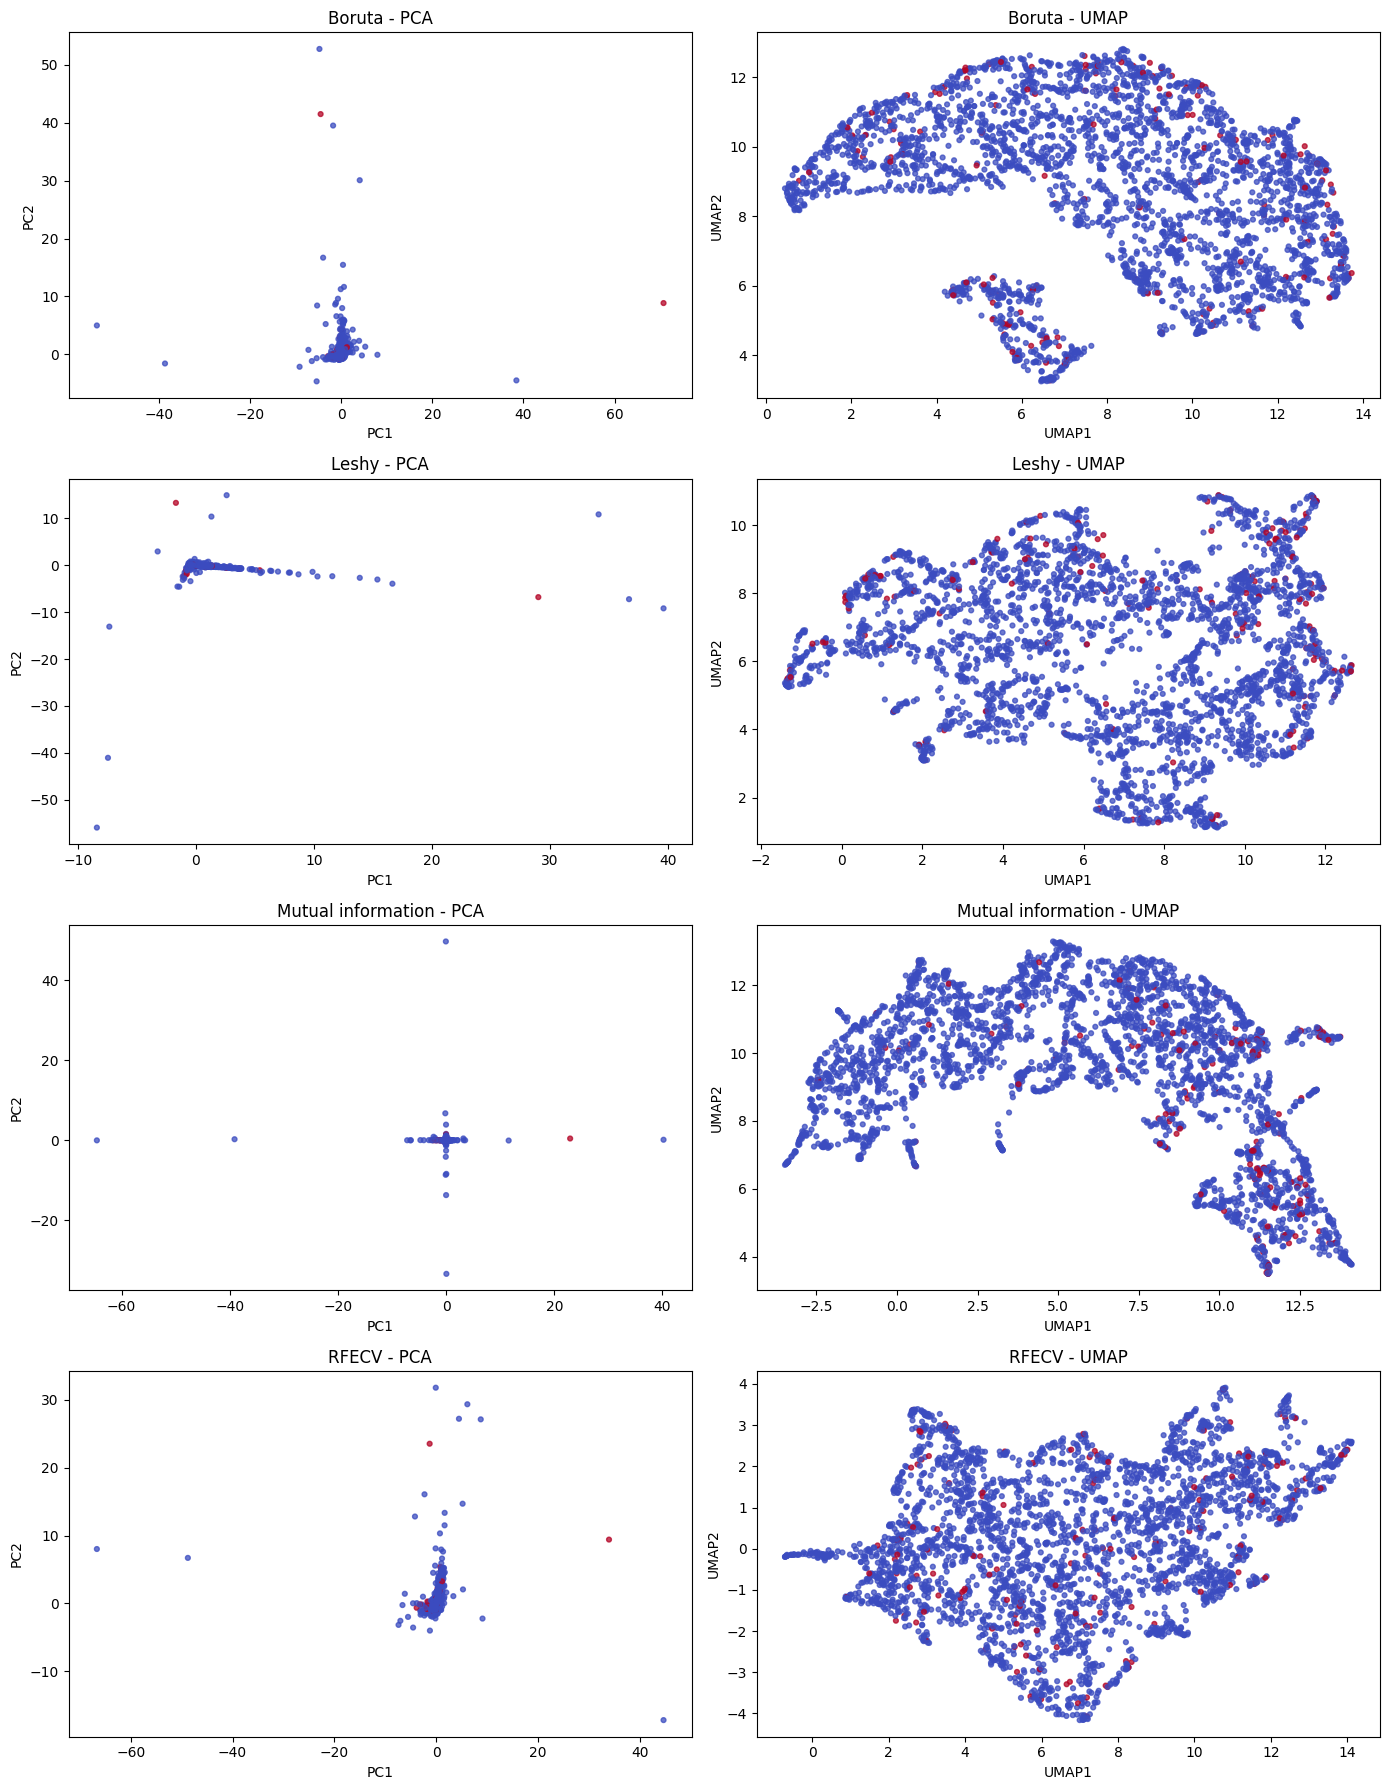

Porównanie jakości wizualizacji:


,method,pca_silhouette,umap_silhouette
0,Leshy,0.273130,0.082404
1,Boruta,0.412006,0.051495
2,RFECV,0.240933,0.031956
3,Mutual information,0.299792,0.014078



Najlepiej wyglądającą redukcję wymiaru daje Leshy.


In [36]:
# Wizualizacje PCA i UMAP dla każdego zestawu cech.
visual_scores = []
fig, axes = plt.subplots(len(feature_sets), 2, figsize=(14, 18))

for row_idx, (method_name, selected_features) in enumerate(feature_sets.items()):
    X_test_selected = X_test_corr[selected_features]

    # Skalujemy tylko na potrzeby wizualizacji, bo PCA i UMAP lepiej działają na cechach w podobnej skali.
    scaler = StandardScaler()
    X_test_scaled = scaler.fit_transform(X_test_selected)

    pca_embedding = PCA(n_components=2).fit_transform(X_test_scaled)
    umap_embedding = UMAP(n_components=2, random_state=0).fit_transform(X_test_scaled)

    pca_silhouette = silhouette_score(pca_embedding, y_test_bankruptcy)
    umap_silhouette = silhouette_score(umap_embedding, y_test_bankruptcy)

    visual_scores.append({
        "method": method_name,
        "pca_silhouette": pca_silhouette,
        "umap_silhouette": umap_silhouette,
    })

    axes[row_idx, 0].scatter(
        pca_embedding[:, 0],
        pca_embedding[:, 1],
        c=y_test_bankruptcy,
        cmap="coolwarm",
        s=12,
        alpha=0.75,
    )
    axes[row_idx, 0].set_title(f"{method_name} - PCA")
    axes[row_idx, 0].set_xlabel("PC1")
    axes[row_idx, 0].set_ylabel("PC2")

    axes[row_idx, 1].scatter(
        umap_embedding[:, 0],
        umap_embedding[:, 1],
        c=y_test_bankruptcy,
        cmap="coolwarm",
        s=12,
        alpha=0.75,
    )
    axes[row_idx, 1].set_title(f"{method_name} - UMAP")
    axes[row_idx, 1].set_xlabel("UMAP1")
    axes[row_idx, 1].set_ylabel("UMAP2")

plt.tight_layout()
plt.show()

visual_scores_df = pd.DataFrame(visual_scores).sort_values("umap_silhouette", ascending=False).reset_index(drop=True)
print("Porównanie jakości wizualizacji:")
display(visual_scores_df)
print()
print(f"Najlepiej wyglądającą redukcję wymiaru daje {visual_scores_df.loc[0, 'method']}.")

Metody selekcji dały różne podzbiory cech (Boruta: 25, Leshy: 11, MI: 10, RFECV: 30). Najlepszy wynik klasyfikacji uzyskał RFECV (AUROC 0.904), a najsłabszy MI (AUROC 0.836). W redukcji wymiarowości UMAP najwyższy silhouette ma Leshy, natomiast w PCA lepiej wypada Boruta. Mimo to klasy pozostają częściowo wymieszane, więc wizualizację należy traktować pomocniczo względem AUROC